# Exploratory Data Analysis - Multivariate EDA

**Contributors:**  
Danny Schönhals,  
Athithya Mariyanayagam

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

---
## Task 1: Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh

Load the **survey data for 2019**.

- Is **BikePgh membership** and **previous experience of encountering autonomous vehicles as a pedestrian** related to the **approval of Pittsburgh as a proving ground**? Examine this question in the following way:
  - Compute a **contingency table** that displays the relationship between the relevant variables. Restrict membership and experience to **"yes" and "no"** answers and ensure a **meaningful order** for all ordinal features.
  - Create a **heatmap** of the **relative** frequencies.
  - Add your **interpretation** of the results in markdown.

In [2]:
# Load the survey data for 2019
# Load the combined 2019 survey data prepared in the previous lab (adjust filepath if needed)
df_av = pd.read_csv("data/av_survey_data/avsurvey2019data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_av.head()

Shape: (795, 23)


,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,Approve,No,Not sure,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,Neutral,No,No,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,Disapprove,Not sure,Yes,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,Disapprove,Yes,Yes,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,Neutral,No,No,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [3]:
df_av_filtered = df_av[
    (df_av['BikePghMember'].isin(['Yes', 'No'])) &
    (df_av['SharedPedestrian'].isin(['Yes', 'No'])) &
    (df_av['ProvingGround'].isin(['Approve', 'Neutral', 'Disapprove', 'Somewhat Disapprove', 'Somewhat Approve']))
].copy()

# Meaningful ordinal order: most negative → most positive
proving_ground_order = ['Disapprove', 'Somewhat Disapprove', 'Neutral', 'Somewhat Approve', 'Approve']
df_av_filtered['ProvingGround'] = pd.Categorical(
    df_av_filtered['ProvingGround'],
    categories=proving_ground_order,
    ordered=True
)

contingency_table = pd.crosstab(
    index=[df_av_filtered['BikePghMember'], df_av_filtered['SharedPedestrian']],
    columns=df_av_filtered['ProvingGround'],
    margins=True
)

contingency_table.index.names = ['BikePgh Member', 'Shared w/ Pedestrian']
contingency_table.columns = contingency_table.columns.astype(str)
contingency_table.columns.name = 'Proving Ground Approval'

# Use iloc[-1] to safely get the grand total scalar from the 'All' margin row
grand_total = contingency_table['All'].iloc[-1]

for col in proving_ground_order + ['All']:
    contingency_table[f'{col} (%)'] = (contingency_table[col] / grand_total).map('{:.1%}'.format)

contingency_table

Proving Ground Approval              Disapprove  Somewhat Disapprove  Neutral  \
BikePgh Member Shared w/ Pedestrian                                             
No             No                            16                    9       16   
               Yes                           14                   20       19   
Yes            No                             8                   11       14   
               Yes                           16                   23       18   
All                                          54                   63       67   

Proving Ground Approval              Somewhat Approve  Approve  All  \
BikePgh Member Shared w/ Pedestrian                                   
No             No                                  22       43  106   
               Yes                                 37      101  191   
Yes            No                                  29       55  117   
               Yes                                 52      132  241   
All                                               140      331  655   

Proving Ground Approval             Disapprove (%) Somewhat Disapprove (%)  \
BikePgh Member Shared w/ Pedestrian                                          
No             No                             2.4%                    1.4%   
               Yes                            2.1%                    3.1%   
Yes            No                             1.2%                    1.7%   
               Yes                            2.4%                    3.5%   
All                                           8.2%                    9.6%   

Proving Ground Approval             Neutral (%) Somewhat Approve (%)  \
BikePgh Member Shared w/ Pedestrian                                    
No             No                          2.4%                 3.4%   
               Yes                         2.9%                 5.6%   
Yes            No                          2.1%                 4.4%   
               Yes                         2.7%                 7.9%   
All                                       10.2%                21.4%   

Proving Ground Approval             Approve (%) All (%)  
BikePgh Member Shared w/ Pedestrian                      
No             No                          6.6%   16.2%  
               Yes                        15.4%   29.2%  
Yes            No                          8.4%   17.9%  
               Yes                        20.2%   36.8%  
All                                       50.5%  100.0%

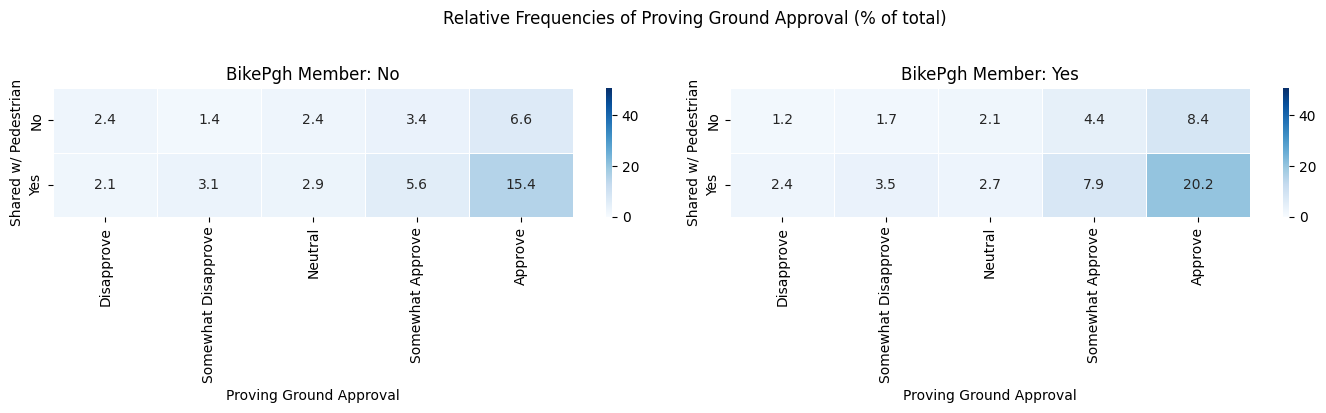

In [4]:
# Relative frequencies (% of grand total), exclude margins
heatmap_data = contingency_table.loc[
    contingency_table.index.get_level_values(-1) != 'All',
    proving_ground_order
].div(grand_total) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, member in zip(axes, ['No', 'Yes']):
    data = heatmap_data.xs(member, level='BikePgh Member')
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax, vmin=0, vmax=heatmap_data.values.max())
    ax.set_title(f'BikePgh Member: {member}')
    ax.set_xlabel('Proving Ground Approval')
    ax.set_ylabel('Shared w/ Pedestrian')

plt.suptitle('Relative Frequencies of Proving Ground Approval (% of total)', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**

"Approve" is the dominant response across all groups (50.5%). Members with pedestrian AV experience have the highest approval rate (20.2%), while non-members without pedestrian experience have the lowest (6.6%). Both BikePgh membership and pedestrian experience are positively associated with approval of Pittsburgh as a proving ground.

---
- To investigate the **relationship between the perceived safety** in the presence of autonomous vs. manually driven vehicles:
  - Compute **Kendall's tau**
  - Display a **heatmap of the relative frequencies** for all categories
  
  Add your interpretation of the results in markdown. **How does the information differ between the heatmap and the correlation coefficient?**

In [11]:
from scipy import stats

# Drop rows where either rating is missing
df_safe = df_av[['SafeAv', 'SafeHuman']].dropna()

tau, p_value = stats.kendalltau(df_safe['SafeAv'], df_safe['SafeHuman'])

print(f"Kendall's tau: {tau:.4f}")
print(f"p-value:       {p_value:.4f}")

Kendall's tau: -0.0283
p-value:       0.3476


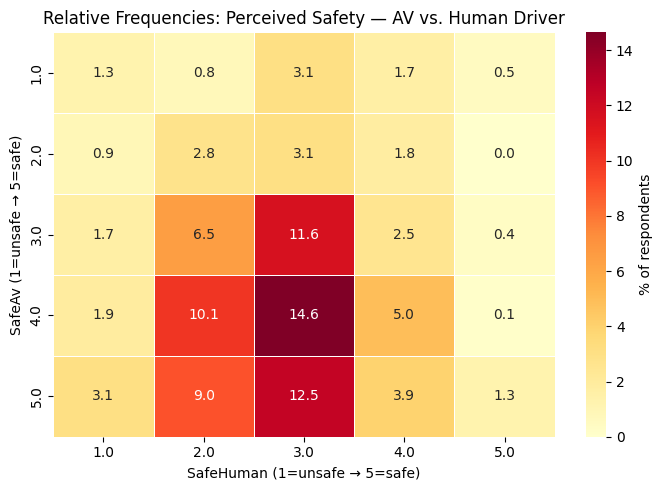

In [12]:
# Crosstab of SafeAv vs SafeHuman
safe_crosstab = pd.crosstab(
    index=df_safe['SafeAv'],
    columns=df_safe['SafeHuman'],
    margins=False
)
safe_crosstab.index.name = 'SafeAv (1=unsafe → 5=safe)'
safe_crosstab.columns.name = 'SafeHuman (1=unsafe → 5=safe)'

# Relative frequencies
safe_rel = safe_crosstab.div(safe_crosstab.values.sum()) * 100

plt.figure(figsize=(7, 5))
sns.heatmap(safe_rel, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of respondents'})
plt.title('Relative Frequencies: Perceived Safety — AV vs. Human Driver')
plt.tight_layout()
plt.show()

**Interpretation:**

Kendall's tau = −0.028 (p = 0.348) close to zero and not statistically significant, indicating no monotonic relationship between perceived AV safety and perceived human driver safety.

The heatmap shows where respondents actually cluster across all rating combinations. Unlike tau, it can reveal non-linear patterns or where the majority of responses concentrate, providing more detail than a single correlation coefficient.

---
- Are **respondents who feel safe around autonomous vehicles** equally likely to **argue for a 25-mph speed limit**?  
  Use a **bar chart** to investigate this question and explain your observations.  
  Restrict answers to the question on speed limits to **"yes" and "no"**.

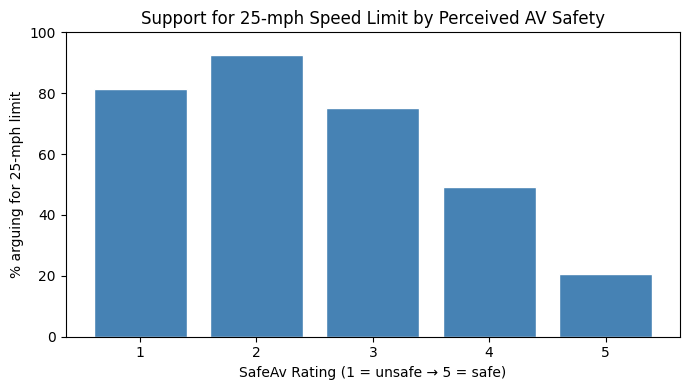

In [13]:
# Filter: restrict speed limit answers to 'Yes' and 'No' only
df_speed = df_av[df_av['Speed25Mph'].isin(['Yes', 'No'])].dropna(subset=['SafeAv'])

# Proportion arguing for 25-mph speed limit per SafeAv rating
speed_prop = (
    df_speed.groupby('SafeAv')['Speed25Mph']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion (%)')
    .reset_index()
)
speed_yes = speed_prop[speed_prop['Speed25Mph'] == 'Yes']

plt.figure(figsize=(7, 4))
plt.bar(speed_yes['SafeAv'].astype(int), speed_yes['Proportion (%)'], color='steelblue', edgecolor='white')
plt.xlabel('SafeAv Rating (1 = unsafe → 5 = safe)')
plt.ylabel('% arguing for 25-mph limit')
plt.title('Support for 25-mph Speed Limit by Perceived AV Safety')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretation:**

There is a clear negative trend: support for the 25-mph limit drops from ~92% at SafeAv = 2 to ~21% at SafeAv = 5. Respondents who feel unsafe around AVs are far more likely to argue for a speed restriction than those who feel safe.

---
## Task 2: Degradation Measurement of Robot Arm Position Accuracy

- Compute the **maximum deviation in both directions** (positive and negative) between the actual and the target joint position **for each trial and joint**.
- Compute the **point-biserial correlations** between the resulting metrics and the **speed** as well as the **load condition**. Describe your findings.

In [14]:
import ast
import os

DATA_PATH = 'data/robot_position_accuracy/'
files = [f for f in os.listdir(DATA_PATH) if f.startswith('ur5testresult') and f.endswith('.csv')]
print(f"{len(files)} trial files found")
print('\n'.join(files[:5]))

18 trial files found
ur5testresult_coldstart_fullspeed_payload4.5lb_1.csv
ur5testresult_coldstart_fullspeed_payload4.5lb_2.csv
ur5testresult_coldstart_fullspeed_payload4.5lb_3.csv
ur5testresult_coldstart_halfspeed_payload4.5lb_1.csv
ur5testresult_coldstart_halfspeed_payload4.5lb_2.csv


In [16]:
results = []

for fname in files:
    is_fullspeed = 'fullspeed' in fname
    is_heavy     = 'payload4.5lb' in fname

    errors = {f'J{j+1}': [] for j in range(6)}

    with open(DATA_PATH + fname, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = ast.literal_eval(line)
            target = row[1]
            actual = row[2]
            for j in range(6):
                errors[f'J{j+1}'].append(actual[j] - target[j])

    record = {'file': fname, 'speed_full': int(is_fullspeed), 'load_heavy': int(is_heavy)}
    for j in range(1, 7):
        record[f'J{j}_max_pos'] = max(errors[f'J{j}'])
        record[f'J{j}_max_neg'] = min(errors[f'J{j}'])

    results.append(record)

df_trials = pd.DataFrame(results)
df_trials.head()

,file,speed_full,load_heavy,J1_max_pos,J1_max_neg,J2_max_pos,J2_max_neg,J3_max_pos,J3_max_neg,J4_max_pos,J4_max_neg,J5_max_pos,J5_max_neg,J6_max_pos,J6_max_neg
0,ur5testresult_coldstart_fullspeed_payload4.5lb_1.csv,1,1,0.065297,-0.082712,0.068525,-0.067509,0.061875,-0.050115,0.060207,-0.078769,0.025279,-0.029268,0.014306,-0.013901
1,ur5testresult_coldstart_fullspeed_payload4.5lb_2.csv,1,1,0.083488,-0.062795,0.082666,-0.074703,0.072736,-0.048827,0.077034,-0.070546,0.026435,-0.029383,0.014991,-0.012129
2,ur5testresult_coldstart_fullspeed_payload4.5lb_3.csv,1,1,0.075245,-0.106130,0.053885,-0.069195,0.071118,-0.053309,0.067187,-0.073159,0.023521,-0.033095,0.013626,-0.013377
3,ur5testresult_coldstart_halfspeed_payload4.5lb_1.csv,0,1,0.048710,-0.048322,0.037021,-0.049887,0.036911,-0.035857,0.045618,-0.068646,0.020476,-0.023168,0.014428,-0.011342
4,ur5testresult_coldstart_halfspeed_payload4.5lb_2.csv,0,1,0.040011,-0.057839,0.033346,-0.037713,0.037558,-0.028970,0.038837,-0.040121,0.021595,-0.022599,0.005452,-0.008199


In [17]:
from scipy.stats import pointbiserialr

deviation_cols = [f'J{j}_{d}' for j in range(1, 7) for d in ('max_pos', 'max_neg')]

rows = []
for col in deviation_cols:
    r_speed, p_speed = pointbiserialr(df_trials['speed_full'], df_trials[col])
    r_load,  p_load  = pointbiserialr(df_trials['load_heavy'],  df_trials[col])
    rows.append({
        'Metric': col,
        'r (speed)': round(r_speed, 3), 'p (speed)': round(p_speed, 3),
        'r (load)':  round(r_load,  3), 'p (load)':  round(p_load,  3),
    })

df_corr = pd.DataFrame(rows)
df_corr

,Metric,r (speed),p (speed),r (load),p (load)
0,J1_max_pos,0.677,0.002,0.016,0.950
1,J1_max_neg,-0.808,0.000,-0.040,0.875
2,J2_max_pos,0.837,0.000,-0.047,0.852
3,J2_max_neg,-0.425,0.079,-0.202,0.421
4,J3_max_pos,0.876,0.000,0.133,0.599
5,J3_max_neg,-0.903,0.000,0.029,0.910
6,J4_max_pos,0.600,0.008,0.243,0.331
7,J4_max_neg,-0.775,0.000,-0.254,0.310
8,J5_max_pos,0.599,0.009,-0.229,0.362
9,J5_max_neg,-0.234,0.351,-0.523,0.026


**Findings:**

**Speed** strongly influences most joints (J1–J5): at full speed, the robot arm deviates more from its target position. J3 is affected the most.

**Load** (payload weight) has almost no effect on J1–J4. Only J5 and J6 the joints closest to the end of the arm deviate noticeably under heavier load.